In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import mlflow
import mlflow.pytorch
from typing import Dict, List, Tuple
from tqdm.notebook import tqdm

from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer
from pytorch_forecasting.data import NaNLabelEncoder
from torch.utils.data import DataLoader

from training.data_loading import *
from training.loss_funcs import *

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision set to 'medium'")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device           : {DEVICE}")

PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision set to 'medium'
Device           : cuda


In [2]:
weather_cols_all = [
    'temperature_2m', 'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m',
    'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low',
    'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure',
    'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m',
    'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance'
]

other_cols = [
    'dam_price', 'buy_bm_price', 'sell_bm_price',
    'max_power', 'max_solar', 'max_ev'
]

cat_columns = [
    'eic_code', 'dso_desc', 'station_type', 'oblast',
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

static_cols = [
    'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast'
]

calendar_cols = [
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

time_cols = ['datetime', 'time_idx']

FUTURE_REALS = weather_cols_all + calendar_cols + other_cols
# static reals (numeric only)
STATIC_REALS = ['latitude', 'longitude']
# static categoricals
STATIC_CATS  = ['dso_desc', 'station_type', 'oblast']
# time-varying categoricals
TIME_VAR_CATS = ['Month', 'Day', 'Hour', 'day_of_week', 'season']

print(f"y col is: {Y_COL}, group col is: {GROUP_COL}")
print(f"future reals ({len(FUTURE_REALS)}): {FUTURE_REALS}")

y col is: sum_of_kWh, group col is: eic_code
future reals (29): ['temperature_2m', 'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance', 'Month', 'Day', 'Hour', 'day_of_week', 'season', 'dam_price', 'buy_bm_price', 'sell_bm_price', 'max_power', 'max_solar', 'max_ev']


In [3]:
print("Loading train â€¦")
train = load_and_prepare(TRAIN_PATH_WITH_DATETME)

print("Loading val   â€¦")
val = load_and_prepare(VAL_PATH_WITH_DATETME)

print("Loading test  â€¦")
test = load_and_prepare(TEST_PATH_WITH_DATETME)

print(f"train: {train.shape}")
print(f"val  : {val.shape}")
print(f"test : {test.shape}")

Loading train â€¦
Loading val   â€¦
Loading test  â€¦
train: (4586151, 38)
val  : (293880, 38)
test : (295430, 38)


In [4]:
# # Uncomment to subsample stations if training is too slow
# TARGET_STATIONS = 395
# station_stats = (
#     train.groupby(GROUP_COL)
#     .agg(rows=(Y_COL, "count"))
#     .reset_index()
#     .sort_values("rows", ascending=False)
# )
# sampled_stations = station_stats.sample(
#     n=TARGET_STATIONS, random_state=42
# )[GROUP_COL].values
# print(f"Stations: {len(sampled_stations)}")
# train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
# val   = val[val[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
# test  = test[test[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
# print(f"Train rows : {len(train):,}")
# print(f"Val rows   : {len(val):,}")
# print(f"Test rows  : {len(test):,}")

In [5]:
training_cutoff = train["time_idx"].max()
val_cutoff      = val["time_idx"].max()
test_cutoff     = test["time_idx"].max()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

training cutoff : 13125
val cutoff      : 13869
test cutoff     : 14617


In [6]:
# â”€â”€ Hyperparameters â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
MAX_ENCODER_LENGTH = 168   # 1 week of hourly history as context
MAX_PREDICTION_LENGTH = 48 # 48-hour forecast horizon

BATCH_SIZE   = 128
NUM_WORKERS  = 4
MAX_EPOCHS   = 30
LEARNING_RATE = 1e-3
HIDDEN_SIZE  = 128
NUM_LAYERS   = 2
DROPOUT      = 0.1

print(f"Encoder length  : {MAX_ENCODER_LENGTH} hours")
print(f"Prediction length: {MAX_PREDICTION_LENGTH} hours")

Encoder length  : 168 hours
Prediction length: 48 hours


In [7]:
class MoneyLoss(nn.Module):
    """
    Differentiable surrogate of money() for use as a PyTorch training loss.

    Prices are looked up from a precomputed dict keyed by time_idx so that
    the DataLoader only needs to return y and time_idx in each batch.
    The dict is built once from the full concatenated train+val+test frames.
    """

    def __init__(self, price_lookup: Dict[int, Tuple[float, float, float]]):
        """
        price_lookup: {time_idx -> (dam_price, sell_bm_price, buy_bm_price)}
        """
        super().__init__()
        # store as tensors for fast indexing
        max_idx = max(price_lookup.keys()) + 1
        dam   = torch.zeros(max_idx)
        sell  = torch.zeros(max_idx)
        buy   = torch.zeros(max_idx)
        for idx, (d, s, b) in price_lookup.items():
            dam[idx]  = d
            sell[idx] = s
            buy[idx]  = b
        self.register_buffer("dam",  dam)
        self.register_buffer("sell", sell)
        self.register_buffer("buy",  buy)

    def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor,
                time_idx: torch.Tensor) -> torch.Tensor:
        """
        y_pred, y_true : (batch, horizon)
        time_idx       : (batch, horizon)  â€” the global time index of every step
        """
        flat_idx = time_idx.long().reshape(-1)
        price    = self.dam[flat_idx].reshape_as(y_pred)  / 1000.0
        sell_p   = self.sell[flat_idx].reshape_as(y_pred) / 1000.0
        buy_p    = self.buy[flat_idx].reshape_as(y_pred)  / 1000.0

        ordered  = y_pred * price
        diff     = y_pred - y_true
        real_spend = (
            ordered
            - torch.where(diff > 0, sell_p * diff,  torch.zeros_like(diff))
            - torch.where(diff < 0, buy_p  * diff,  torch.zeros_like(diff))
        )
        min_spend = y_true * price
        return (real_spend - min_spend).sum()/(min_spend.sum()/100)

In [8]:
# Build price lookup dict from all splits (prices depend only on time_idx/datetime)
all_data = pd.concat([train, val, test], ignore_index=True)
price_lookup = (
    all_data
    .drop_duplicates("time_idx")
    .set_index("time_idx")[["dam_price", "sell_bm_price", "buy_bm_price"]]
    .apply(tuple, axis=1)
    .to_dict()
)
print(f"Price lookup entries: {len(price_lookup):,}")

Price lookup entries: 14,618


In [9]:
# The dataset uses training_cutoff to split internally.
full_train_val = pd.concat([train, val], ignore_index=True)

# Ensure cat columns are strings (pytorch-forecasting requirement)
for col in cat_columns:
    for df in [full_train_val, test]:
        df[col] = df[col].astype(str)


train_dataset = TimeSeriesDataSet(
    full_train_val[full_train_val.time_idx <= training_cutoff],
    time_idx="time_idx",
    target=Y_COL,
    group_ids=[GROUP_COL],
    min_encoder_length=MAX_ENCODER_LENGTH,   # fixed, same as max
    max_encoder_length=MAX_ENCODER_LENGTH,
    min_prediction_length=MAX_PREDICTION_LENGTH,  # fixed, same as max
    max_prediction_length=MAX_PREDICTION_LENGTH,
    static_reals=STATIC_REALS,
    static_categoricals=STATIC_CATS,
    time_varying_known_reals=[
        c for c in FUTURE_REALS
        if c not in cat_columns and c not in STATIC_REALS
    ],
    time_varying_known_categoricals=TIME_VAR_CATS,
    time_varying_unknown_reals=[Y_COL],
    target_normalizer=GroupNormalizer(
        groups=[GROUP_COL], transformation="softplus"
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=False,
)

val_dataset = TimeSeriesDataSet.from_dataset(
    train_dataset,
    full_train_val,
    predict=True,
    stop_randomization=True,
)

# Use to_dataloader() so pytorch-forecasting's _collate_fn is used.
# DataLoader(...) with default_collate fails because weight is None
# when no weight column is set in the dataset.
train_loader = train_dataset.to_dataloader(
    train=True, batch_size=BATCH_SIZE, num_workers=0
)
val_loader = val_dataset.to_dataloader(
    train=False, batch_size=BATCH_SIZE * 2, num_workers=0
)

print(f"Train batches : {len(train_loader):,}")
print(f"Val   batches : {len(val_loader):,}")

Train batches : 35,165
Val   batches : 2


In [10]:
class GRUForecaster(nn.Module):
    """
    GRU-based multi-step forecaster consuming pytorch-forecasting batch dicts.

    pytorch-forecasting packs ALL categoricals into encoder_cat / decoder_cat in the order
    [static_cats, tv_known_cats] (group_ids are in x["groups"], not here).
    ALL reals go into encoder_cont in the order [target, static_reals, tv_known_reals, ..., extras].
    decoder_cont has the same columns as encoder_cont.

    We receive the column positions of static / tv features as index buffers
    so the forward pass can slice the right columns without hard-coding offsets.
    """

    def __init__(
        self,
        n_cont_encoder: int,
        n_cont_decoder: int,
        cat_embedding_dims: List[Tuple[int, int]],       # TV cat (vocab, emb_dim)
        static_real_dim: int,
        static_cat_embedding_dims: List[Tuple[int, int]], # static cat (vocab, emb_dim)
        hidden_size: int = 128,
        num_layers: int = 2,
        dropout: float = 0.1,
        prediction_length: int = 48,
        static_real_idx: List[int] = None,  # positions of static reals in encoder_cont
        static_cat_idx:  List[int] = None,  # positions of static cats  in encoder_cat
        tv_cat_idx_enc:  List[int] = None,  # positions of TV    cats  in encoder_cat / decoder_cat
    ):
        super().__init__()
        self.prediction_length = prediction_length

        # ── Embeddings ───────────────────────────────────────────────────────
        self.tv_cat_embeddings = nn.ModuleList([
            nn.Embedding(vocab, dim) for vocab, dim in cat_embedding_dims
        ])
        self.static_cat_embeddings = nn.ModuleList([
            nn.Embedding(vocab, dim) for vocab, dim in static_cat_embedding_dims
        ])

        tv_emb_dim     = sum(d for _, d in cat_embedding_dims)
        static_emb_dim = sum(d for _, d in static_cat_embedding_dims)

        encoder_input_size = n_cont_encoder + tv_emb_dim
        decoder_input_size = n_cont_decoder + tv_emb_dim
        static_input_size  = static_real_dim + static_emb_dim

        # Static context projection → initial hidden state
        self.static_proj = nn.Linear(static_input_size, hidden_size * num_layers)

        # ── Encoder GRU ─────────────────────────────────────────────────────
        self.encoder_gru = nn.GRU(
            input_size=encoder_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # ── Decoder GRU ─────────────────────────────────────────────────────
        self.decoder_gru = nn.GRU(
            input_size=decoder_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(hidden_size, 1)

        # Index buffers – moved to the right device automatically with .to(device)
        self.register_buffer("static_real_idx", torch.tensor(static_real_idx or [], dtype=torch.long))
        self.register_buffer("static_cat_idx",  torch.tensor(static_cat_idx  or [], dtype=torch.long))
        self.register_buffer("tv_cat_idx_enc",  torch.tensor(tv_cat_idx_enc  or [], dtype=torch.long))

    def _embed_tv_cats(self, cat_tensor: torch.Tensor) -> torch.Tensor:
        """cat_tensor: (B, T, n_cat_tv) → (B, T, total_emb_dim)"""
        parts = [
            emb(cat_tensor[..., i].clamp(0, emb.num_embeddings - 1))
            for i, emb in enumerate(self.tv_cat_embeddings)
        ]
        return torch.cat(parts, dim=-1) if parts else torch.zeros(
            cat_tensor.shape[0], cat_tensor.shape[1], 0, device=cat_tensor.device
        )

    def _embed_static_cats(self, cat_tensor: torch.Tensor) -> torch.Tensor:
        """cat_tensor: (B, n_static_cat) → (B, total_emb_dim)"""
        parts = [
            emb(cat_tensor[:, i].clamp(0, emb.num_embeddings - 1))
            for i, emb in enumerate(self.static_cat_embeddings)
        ]
        return torch.cat(parts, dim=-1) if parts else torch.zeros(
            cat_tensor.shape[0], 0, device=cat_tensor.device
        )

    def forward(self, x: Dict[str, torch.Tensor]) -> torch.Tensor:
        enc_cont = x["encoder_cont"]   # (B, T_enc, n_all_reals)
        dec_cont = x["decoder_cont"]   # (B, T_dec, n_all_reals)
        enc_cat  = x["encoder_cat"]    # (B, T_enc, n_static+n_tv) – static_cats + tv_known
        dec_cat  = x["decoder_cat"]    # (B, T_dec, n_static+n_tv) – same columns as encoder_cat

        # ── Static features (constant → take first encoder timestep) ──────
        static_cat_raw = enc_cat[:, 0, self.static_cat_idx]    # (B, n_static_cat)
        static_cat_emb = self._embed_static_cats(static_cat_raw)
        static_real    = enc_cont[:, 0, self.static_real_idx]   # (B, n_static_real)
        static_inp     = torch.cat([static_real, static_cat_emb], dim=-1)

        h0 = self.static_proj(static_inp)                        # (B, H*L)
        h0 = h0.view(h0.shape[0], self.encoder_gru.num_layers, -1)
        h0 = h0.permute(1, 0, 2).contiguous()                   # (L, B, H)

        # ── Encoder ────────────────────────────────────────────────────────
        enc_tv_cat = enc_cat[..., self.tv_cat_idx_enc]           # (B, T_enc, n_tv_cat)
        enc_emb    = self._embed_tv_cats(enc_tv_cat)
        enc_inp    = torch.cat([enc_cont, enc_emb], dim=-1)
        _, h_n     = self.encoder_gru(enc_inp, h0)

        # ── Decoder ────────────────────────────────────────────────────────
        # decoder_cat has the same column layout as encoder_cat; slice TV cats
        dec_tv_cat = dec_cat[..., self.tv_cat_idx_enc]           # (B, T_dec, n_tv_cat)
        dec_emb    = self._embed_tv_cats(dec_tv_cat)
        dec_inp    = torch.cat([dec_cont, dec_emb], dim=-1)
        dec_out, _ = self.decoder_gru(dec_inp, h_n)

        return self.fc_out(self.dropout(dec_out)).squeeze(-1)    # (B, T_dec)

In [11]:
def suggest_embedding_dim(vocab_size: int) -> int:
    return min(50, max(4, vocab_size // 2))

cat_encoders = train_dataset.get_parameters()["categorical_encoders"]

def get_vocab_size(col):
    enc = cat_encoders[col]
    return len(enc.classes_) + 1

tv_cat_dims = [
    (get_vocab_size(col), suggest_embedding_dim(get_vocab_size(col)))
    for col in train_dataset.time_varying_known_categoricals
]

static_cat_dims = [
    (get_vocab_size(col), suggest_embedding_dim(get_vocab_size(col)))
    for col in train_dataset.static_categoricals
]

n_cont_encoder  = len(train_dataset.reals)
n_cont_decoder  = n_cont_encoder   # decoder_cont.shape[-1] == encoder_cont.shape[-1]
static_real_dim = len(train_dataset.static_reals)

# encoder_cat column order matches flat_categoricals:
#   static_categoricals + tv_known_categoricals  (group_ids are in x["groups"], NOT here)
all_cats_enc = (
    list(train_dataset.static_categoricals) +
    list(train_dataset.time_varying_known_categoricals)
)
static_cat_idx = [all_cats_enc.index(c) for c in train_dataset.static_categoricals]
tv_cat_idx_enc = [all_cats_enc.index(c) for c in train_dataset.time_varying_known_categoricals]

# encoder_cont column order matches train_dataset.reals
all_reals       = list(train_dataset.reals)
static_real_idx = [all_reals.index(c) for c in train_dataset.static_reals]

print(f"encoder_cat columns ({len(all_cats_enc)}): {all_cats_enc}")
print(f"static_cat_idx  : {static_cat_idx}  -> {[all_cats_enc[i] for i in static_cat_idx]}")
print(f"tv_cat_idx_enc  : {tv_cat_idx_enc}  -> {[all_cats_enc[i] for i in tv_cat_idx_enc]}")
print(f"encoder_cont (first 5): {all_reals[:5]}")
print(f"static_real_idx : {static_real_idx}  -> {[all_reals[i] for i in static_real_idx]}")
print(f"n_cont_enc/dec  : {n_cont_encoder}")

model = GRUForecaster(
    n_cont_encoder=n_cont_encoder,
    n_cont_decoder=n_cont_decoder,
    cat_embedding_dims=tv_cat_dims,
    static_real_dim=static_real_dim,
    static_cat_embedding_dims=static_cat_dims,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    prediction_length=MAX_PREDICTION_LENGTH,
    static_real_idx=static_real_idx,
    static_cat_idx=static_cat_idx,
    tv_cat_idx_enc=tv_cat_idx_enc,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters : {total_params:,}")
print(model)

encoder_cat columns (8): ['dso_desc', 'station_type', 'oblast', 'Month', 'Day', 'Hour', 'day_of_week', 'season']
static_cat_idx  : [0, 1, 2]  -> ['dso_desc', 'station_type', 'oblast']
tv_cat_idx_enc  : [3, 4, 5, 6, 7]  -> ['Month', 'Day', 'Hour', 'day_of_week', 'season']
encoder_cont (first 5): ['latitude', 'longitude', 'encoder_length', 'sum_of_kWh_center', 'sum_of_kWh_scale']
static_real_idx : [0, 1]  -> ['latitude', 'longitude']
n_cont_enc/dec  : 31
Model parameters : 364,279
GRUForecaster(
  (tv_cat_embeddings): ModuleList(
    (0): Embedding(13, 6)
    (1): Embedding(32, 16)
    (2): Embedding(25, 12)
    (3): Embedding(8, 4)
    (4): Embedding(5, 4)
  )
  (static_cat_embeddings): ModuleList(
    (0): Embedding(28, 14)
    (1): Embedding(8, 4)
    (2): Embedding(24, 12)
  )
  (static_proj): Linear(in_features=32, out_features=256, bias=True)
  (encoder_gru): GRU(73, 128, num_layers=2, batch_first=True, dropout=0.1)
  (decoder_gru): GRU(73, 128, num_layers=2, batch_first=True, drop

In [12]:
def inverse_softplus(y_norm: torch.Tensor, target_scale: torch.Tensor) -> torch.Tensor:
    """Undo GroupNormalizer(transformation='softplus'): y_abs = softplus(y_norm * scale) """
    center = target_scale[:, 0].unsqueeze(1)   # mean  (B, 1)
    scale  = target_scale[:, 1].unsqueeze(1)   # std   (B, 1)
    return torch.nn.functional.softplus(y_norm * scale + center)

In [ ]:
money_loss_fn = MoneyLoss(price_lookup).to(DEVICE)
optimizer     = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3, verbose=True
)

mlflow.set_experiment("gru_energy_forecast")

with mlflow.start_run(run_name="gru_money_loss"):
    mlflow.log_params({
        "model":                  "GRU",
        "hidden_size":            HIDDEN_SIZE,
        "num_layers":             NUM_LAYERS,
        "dropout":                DROPOUT,
        "max_encoder_length":     MAX_ENCODER_LENGTH,
        "max_prediction_length":  MAX_PREDICTION_LENGTH,
        "batch_size":             BATCH_SIZE,
        "learning_rate":          LEARNING_RATE,
        "max_epochs":             MAX_EPOCHS,
        "loss":                   "MoneyLoss",
    })

    best_val_loss = float("inf")

    for epoch in range(1, MAX_EPOCHS + 1):
        # â”€â”€ Train â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        model.train()
        train_loss_total = 0.0
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS} [train]", leave=False)

        for x, (y, weight) in train_bar:
            x            = {k: v.to(DEVICE) for k, v in x.items()}
            y            = y.to(DEVICE)
            time_idx_dec = x["decoder_time_idx"]
            target_scale = x["target_scale"]

            optimizer.zero_grad()
            y_pred = model(x)

            # Denormalise to absolute kWh for MoneyLoss
            # GroupNormalizer.inverse_transform expects {"target_scale": tensor}
            y_pred_denorm = inverse_softplus(y_pred, target_scale)
            y_denorm      = inverse_softplus(y,      target_scale)

            loss = money_loss_fn(y_pred_denorm, y_denorm, time_idx_dec)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss_total += loss.item()
            train_bar.set_postfix({"loss": f"{loss.item():.2f}"})

        avg_train_loss = train_loss_total / len(train_loader)

        # â”€â”€ Validate â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        model.eval()
        val_loss_total = 0.0

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS} [val]  ", leave=False)
            for x, (y, weight) in val_bar:
                x            = {k: v.to(DEVICE) for k, v in x.items()}
                y            = y.to(DEVICE)
                time_idx_dec = x["decoder_time_idx"]
                target_scale = x["target_scale"]

                y_pred = model(x)
                y_pred_denorm = inverse_softplus(y_pred, target_scale)
                y_denorm      = inverse_softplus(y,      target_scale)
                loss = money_loss_fn(y_pred_denorm, y_denorm, time_idx_dec)
                val_loss_total += loss.item()

        avg_val_loss = val_loss_total / len(val_loader)
        scheduler.step(avg_val_loss)

        mlflow.log_metrics({
            "train_money_loss": avg_train_loss,
            "val_money_loss":   avg_val_loss,
            "lr":               optimizer.param_groups[0]["lr"],
        }, step=epoch)

        print(
            f"Epoch {epoch:>3}/{MAX_EPOCHS}  "
            f"train_loss={avg_train_loss:.2f}  "
            f"val_loss={avg_val_loss:.2f}"
        )

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "../models/gru/best_gru_fixed_time_idx.pt")
            mlflow.log_artifact("../models/gru/best_gru_fixed_time_idx.pt")
            print(f"  âœ“ new best val_loss={best_val_loss:.2f} â†’ checkpoint saved")

print("Training complete.")
print(f"Best val MoneyLoss : {best_val_loss:.4f}")

Epoch 1/30 [train]:   0%|          | 0/35165 [00:00<?, ?it/s]

In [14]:
model.load_state_dict(torch.load("../models/gru/best_gru_fixed_time_idx.pt", map_location=DEVICE))
model.eval()

GRUForecaster(
  (tv_cat_embeddings): ModuleList(
    (0): Embedding(13, 6)
    (1): Embedding(32, 16)
    (2): Embedding(25, 12)
    (3): Embedding(8, 4)
    (4): Embedding(5, 4)
  )
  (static_cat_embeddings): ModuleList(
    (0): Embedding(28, 14)
    (1): Embedding(8, 4)
    (2): Embedding(24, 12)
  )
  (static_proj): Linear(in_features=32, out_features=256, bias=True)
  (encoder_gru): GRU(73, 128, num_layers=2, batch_first=True, dropout=0.1)
  (decoder_gru): GRU(73, 128, num_layers=2, batch_first=True, dropout=0.1)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc_out): Linear(in_features=128, out_features=1, bias=True)
)

In [15]:
def inverse_softplus(y_norm: torch.Tensor, target_scale: torch.Tensor) -> torch.Tensor:
    center = target_scale[:, 0].unsqueeze(1)
    scale  = target_scale[:, 1].unsqueeze(1)
    return torch.nn.functional.softplus(y_norm * scale + center)


def rolling_predict(
    df: pd.DataFrame,
    dataset_ref: TimeSeriesDataSet,
    horizon: int = MAX_PREDICTION_LENGTH,
) -> pd.DataFrame:
    records = []
    model.eval()

    for grp, gdf in tqdm(df.groupby(GROUP_COL), desc="Stations"):
        gdf   = gdf.sort_values("time_idx").reset_index(drop=True)
        start = gdf["time_idx"].min()
        end   = gdf["time_idx"].max()

        while start <= end:
            enc_start = start - MAX_ENCODER_LENGTH
            dec_end   = start + horizon - 1

            window_df = gdf[
                (gdf["time_idx"] >= enc_start) &
                (gdf["time_idx"] <= dec_end)
            ].reset_index(drop=True)

            # Need full encoder + at least 1 decoder step
            if len(window_df) < MAX_ENCODER_LENGTH + 1:
                start += horizon
                continue

            try:
                # Build a minimal single-row dataset for this window
                # by passing the full df with min_prediction_idx set
                # so pytorch-forecasting selects only this window
                tmp_df = df[
                    (df[GROUP_COL] == grp) &
                    (df["time_idx"] >= enc_start) &
                    (df["time_idx"] <= dec_end)
                ].reset_index(drop=True)

                window_ds = TimeSeriesDataSet.from_dataset(
                    dataset_ref,
                    tmp_df,
                    predict=False,          # ← False avoids predict_mode index bugs
                    stop_randomization=True,
                    min_prediction_idx=start,   # only predict from `start` onward
                )
                loader = window_ds.to_dataloader(
                    train=False, batch_size=64, num_workers=0
                )

                for x, (y_true_batch, _) in loader:
                    target_scale_cpu = x["target_scale"].clone()
                    x = {k: v.to(DEVICE) for k, v in x.items()}

                    with torch.no_grad():
                        y_pred_norm = model(x)

                    y_pred_denorm = inverse_softplus(
                        y_pred_norm, x["target_scale"]
                    ).cpu().numpy()
                    y_true_denorm = inverse_softplus(
                        y_true_batch, target_scale_cpu
                    ).numpy()
                    tidx = x["decoder_time_idx"].cpu().numpy()

                    for b in range(tidx.shape[0]):
                        for t in range(tidx.shape[1]):
                            records.append({
                                GROUP_COL:  grp,
                                "time_idx": int(tidx[b, t]),
                                "pred":     float(y_pred_denorm[b, t]),
                                Y_COL:      float(y_true_denorm[b, t]),
                            })

            except Exception as e:
                pass  # replace with `print(e)` temporarily if still seeing errors

            start += horizon

    result = (
        pd.DataFrame(records)
        .drop_duplicates(subset=[GROUP_COL, "time_idx"])
    )
    meta = df[["time_idx", "datetime", "dam_price", "sell_bm_price", "buy_bm_price"]].drop_duplicates("time_idx")
    return result.merge(meta, on="time_idx", how="left")

for col in cat_columns:
    val[col]  = val[col].astype(str)
    test[col] = test[col].astype(str)

print("Running inference on validation split …")
val_eval = rolling_predict(val, train_dataset)
print(f"val_eval rows : {len(val_eval):,}")

print("Running inference on test split …")
test_eval = rolling_predict(test, train_dataset)
print(f"test_eval rows: {len(test_eval):,}")

Running inference on validation split …


Stations:   0%|          | 0/395 [00:00<?, ?it/s]

val_eval rows : 208,560
Running inference on test split …


Stations:   0%|          | 0/395 [00:00<?, ?it/s]

test_eval rows: 208,560


In [16]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

val_smape_v     = smape(val_eval[Y_COL], val_eval['pred'])
val_rmse_v      = rmse(val_eval[Y_COL], val_eval['pred'])
val_mape_v      = mape(val_eval[Y_COL], val_eval['pred'])
val_money_v     = money(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))
val_money_pct_v = money_pct(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))

test_smape_v     = smape(test_eval[Y_COL], test_eval['pred'])
test_rmse_v      = rmse(test_eval[Y_COL], test_eval['pred'])
test_mape_v      = mape(test_eval[Y_COL], test_eval['pred'])
test_money_v     = money(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))
test_money_pct_v = money_pct(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))

print("â”€â”€ Validation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE     : {val_smape_v:.4f}")
print(f"RMSE      : {val_rmse_v:.4f}")
print(f"MAPE      : {val_mape_v:.2f} %")
print(f"MONEY     : {val_money_v:.4f}")
print(f"MONEY_PCT : {val_money_pct_v:.4f}%")

print("â”€â”€ Test â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE     : {test_smape_v:.4f}")
print(f"RMSE      : {test_rmse_v:.4f}")
print(f"MAPE      : {test_mape_v:.2f} %")
print(f"MONEY     : {test_money_v:.4f}")
print(f"MONEY_PCT : {test_money_pct_v:.4f}%")

with mlflow.start_run(run_id=mlflow.last_active_run().info.run_id):
    mlflow.log_metrics({
        "val_smape":      val_smape_v,
        "val_rmse":       val_rmse_v,
        "val_mape":       val_mape_v,
        "val_money":      val_money_v,
        "val_money_pct":  val_money_pct_v,
        "test_smape":     test_smape_v,
        "test_rmse":      test_rmse_v,
        "test_mape":      test_mape_v,
        "test_money":     test_money_v,
        "test_money_pct": test_money_pct_v,
    })
print(f"MLflow run logged â†’ {mlflow.get_tracking_uri()}")

â”€â”€ Validation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
Aligned samples : 208,560
SMAPE     : 42.1394
RMSE      : 356.3667
MAPE      : 63.81 %
MONEY     : 30173285.1785
MONEY_PCT : 15.1330%
â”€â”€ Test â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
Aligned samples : 208,560
SMAPE     : 43.1618
RMSE      : 372.6726
MAPE      : 65.45 %
MONEY     : 27513525.9110
MONEY_PCT : 13.5490%


AttributeError: 'NoneType' object has no attribute 'info'

In [17]:
def per_station_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for grp, gdf in eval_df.groupby(GROUP_COL):
        rows.append({
            GROUP_COL:   grp,
            "n":         len(gdf),
            "SMAPE":     smape(gdf[Y_COL], gdf["pred"]),
            "RMSE":      rmse(gdf[Y_COL], gdf["pred"]),
            "MAPE":      mape(gdf[Y_COL], gdf["pred"]),
            "MONEY":     money(gdf[Y_COL], gdf["pred"], *_prices(gdf)),
            "MONEY_PCT": money_pct(gdf[Y_COL], gdf["pred"], *_prices(gdf)),
        })
    return pd.DataFrame(rows).sort_values("SMAPE")


test_station_metrics = per_station_metrics(test_eval)

print("Top-10 best stations (test SMAPE):")
print(test_station_metrics.head(10).to_string(index=False))
print("\nBottom-10 worst stations (test SMAPE):")
print(test_station_metrics.tail(10).to_string(index=False))

Top-10 best stations (test SMAPE):
        eic_code   n     SMAPE      RMSE      MAPE        MONEY  MONEY_PCT
62Z9512175266041 528 18.748737 23.881923 19.994087 26564.538817  10.466857
62Z3500556180000 528 20.236660 29.119119 20.892559 25709.180204   8.612953
62Z0760150283041 528 20.801856 22.859226 19.444523 17187.520779   6.343862
62Z588650225523K 528 21.049466 47.486775 18.781424 37235.854076   6.501868
62Z132888029374Z 528 21.446726 20.177055 23.183177 19749.695151  10.630751
62Z6499995405271 528 21.971663 27.478569 21.606902 22282.220739   8.237025
62Z5227218120709 528 21.985221 24.094533 24.876388 26896.926662  14.075452
62Z5387901249939 528 22.111472 26.562374 24.377826 27215.180190  12.331657
62Z8937841078757 528 22.584469 22.212938 21.638858 19763.096745   8.302069
62Z6961364992272 528 23.179803 29.933540 22.927046 27893.730755   9.132733

Bottom-10 worst stations (test SMAPE):
        eic_code   n      SMAPE      RMSE        MAPE        MONEY   MONEY_PCT
62Z7029546479880 528 

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_forecast(df, eic_code, start_dt=None, end_dt=None, title_prefix=""):
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EiC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{title_prefix}{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  MONEY_PCT={money_pct(df[Y_COL], df['pred'], *_prices(df)):.2f}"
        f"  ({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# Example:
# plot_forecast(val_eval,  eic_code="<code>")
# plot_forecast(test_eval, eic_code="<code>", start_dt="2025-08-25", end_dt="2025-08-26")

Best  station (SMAPE): 62Z9512175266041


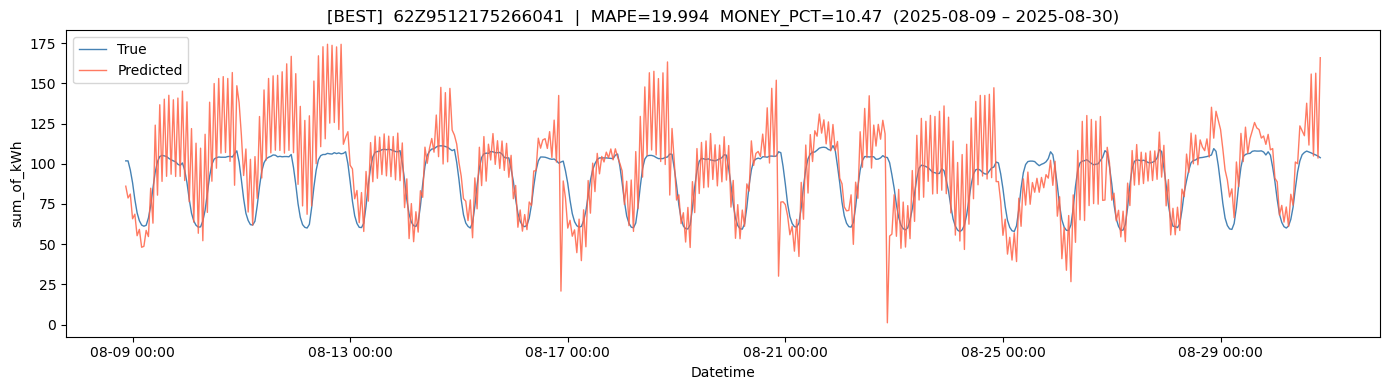

Worst station (SMAPE): 62Z0352290641310


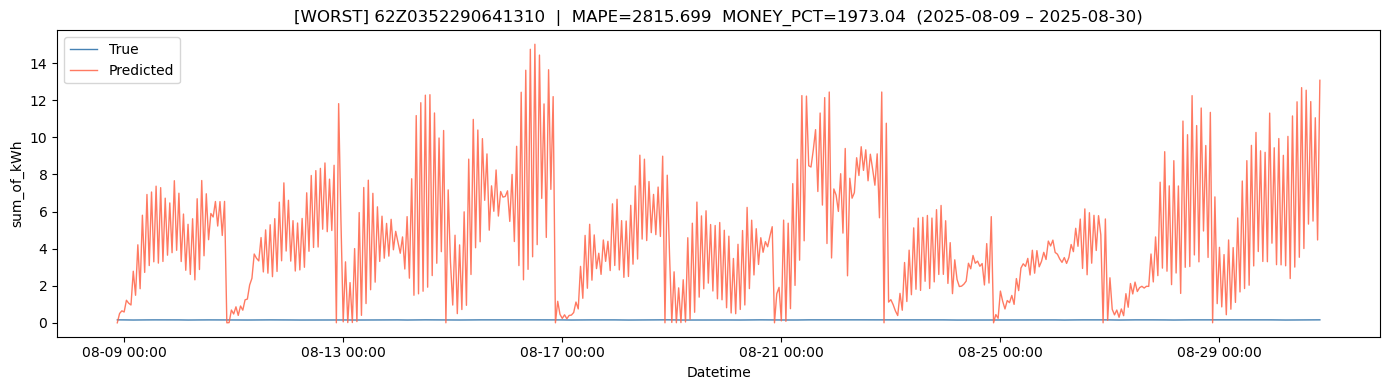

In [19]:
best_station  = test_station_metrics.iloc[0][GROUP_COL]
worst_station = test_station_metrics.iloc[-1][GROUP_COL]

print(f"Best  station (SMAPE): {best_station}")
plot_forecast(test_eval, eic_code=best_station,  title_prefix="[BEST]  ")

print(f"Worst station (SMAPE): {worst_station}")
plot_forecast(test_eval, eic_code=worst_station, title_prefix="[WORST] ")